In [1]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib as plt

In [2]:
Data = pd.read_csv("/kaggle/input/datasets/uom190346a/water-quality-and-potability/water_potability.csv")
Data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [3]:
df = pd.DataFrame(Data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


The results show that Feautures including **ph**, **Sulfate**, **Trihalomethanes** has missing values.

In [4]:
df.shape

(3276, 10)

This Dataset includes: 

* 3276 Samples
* 10 Features


In [5]:
df.describe(include='all')

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
def data_describe(df):
    features = []
    count = []
    unique_val = []
    n_missing = []
    missing_percent = []

    for item in df.columns:
        features.append(item)
        count.append(len(df[item]))
        unique_val.append(len(df[item].unique()))
        n_missing.append(df[item].isna().sum())
        missing_percent.append(round(df[item].isna().mean() *100,2))

    output = pd.DataFrame({'Features': features, '#samples':count,'unique_values':unique_val, '#missing_values':n_missing, '%missing':missing_percent})

    return output

In [7]:
data_describe(df)

,Features,#samples,unique_values,#missing_values,%missing
0,ph,3276,2786,491,14.99
1,Hardness,3276,3276,0,0.00
2,Solids,3276,3276,0,0.00
3,Chloramines,3276,3276,0,0.00
4,Sulfate,3276,2496,781,23.84
5,Conductivity,3276,3276,0,0.00
6,Organic_carbon,3276,3276,0,0.00
7,Trihalomethanes,3276,3115,162,4.95
8,Turbidity,3276,3276,0,0.00
9,Potability,3276,2,0,0.00


<Axes: >

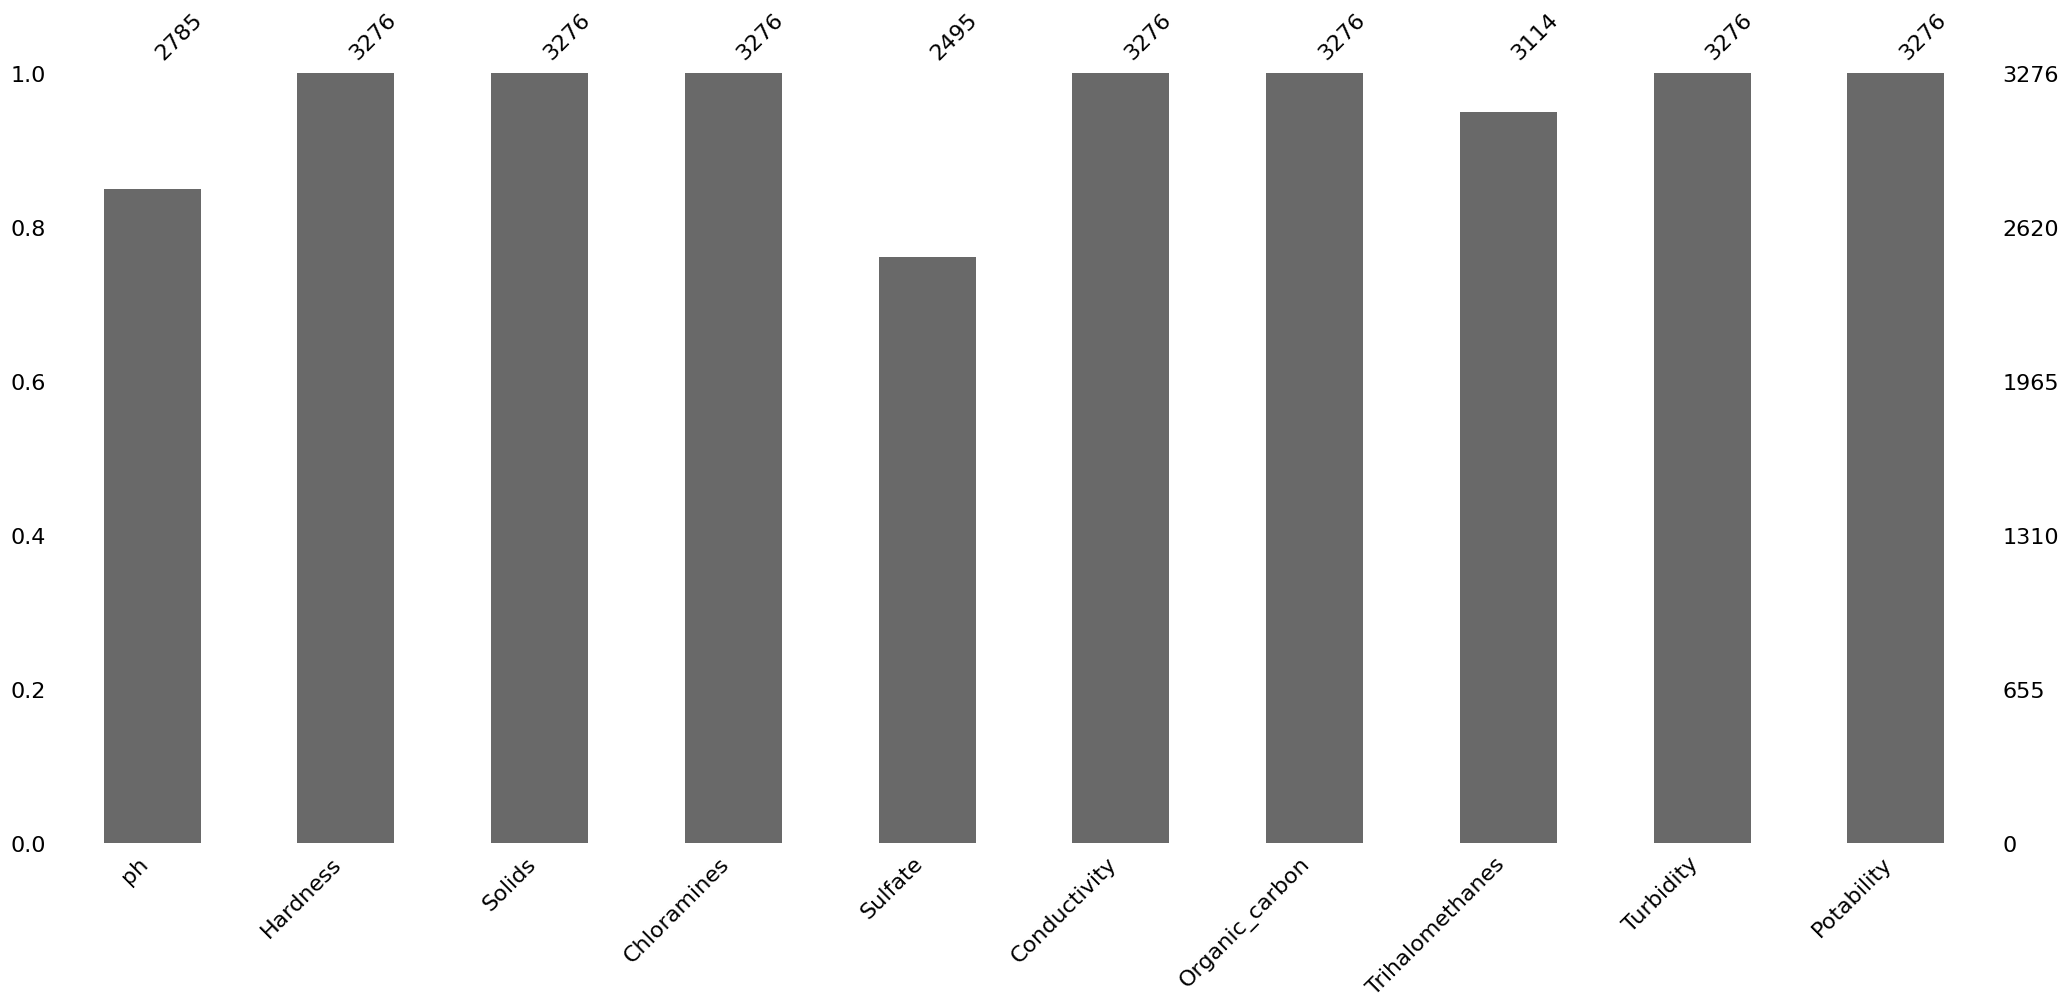

In [8]:
#Visualization of Missing Values
msno.bar(df)

<Axes: >

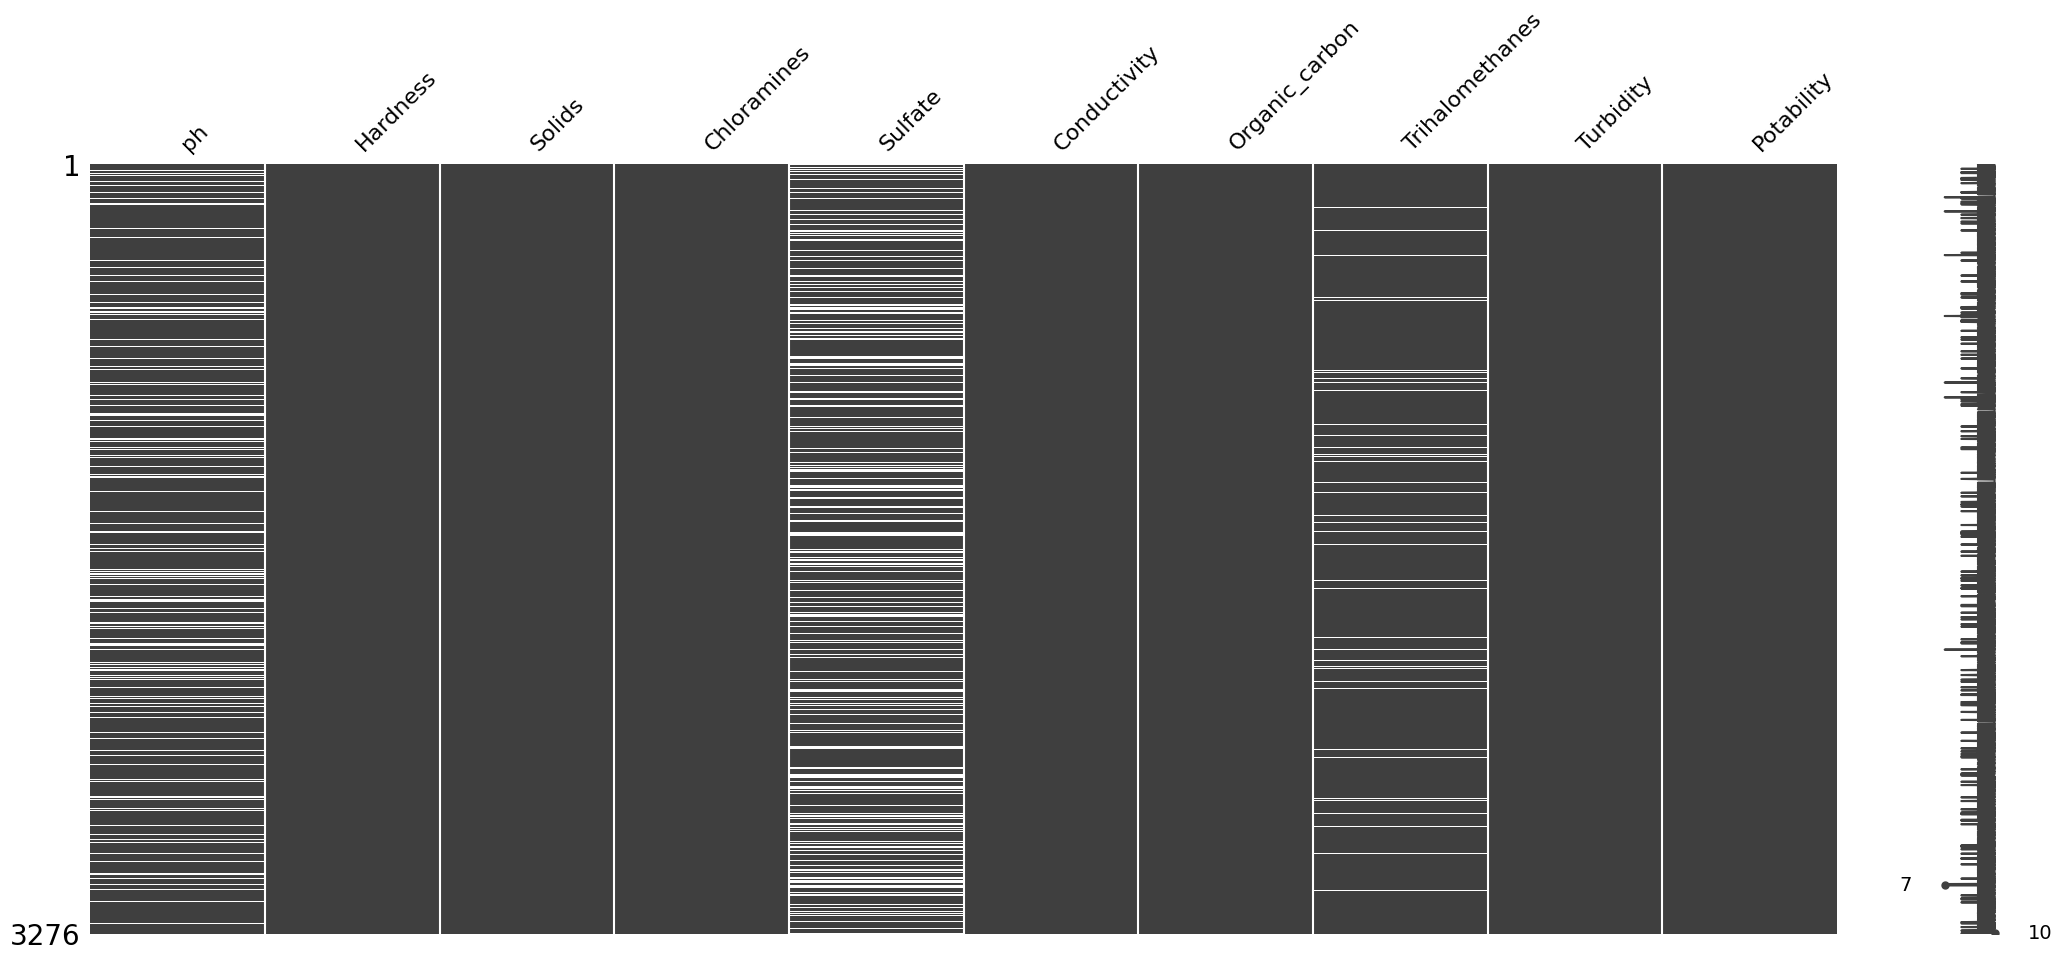

In [9]:
msno.matrix(df)

In [10]:
# Counting the total samples with missing values
missing_val_rows = df.isna().any(axis=1).sum()
print("# rows with missing values:", missing_val_rows)
n_rows = len(df)
missing_val_percent = missing_val_rows/n_rows
print(f"Percentage of rows with missing values:{round(missing_val_percent,2)*100}%")

# rows with missing values: 1265
Percentage of rows with missing values:39.0%


In [11]:
# DataFrame of missing value samples
from IPython.display import display
missing_rows = df[df.isna().any(axis=1)]
display(missing_rows)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
11,7.974522,218.693300,18767.656682,8.110385,NaN,364.098230,14.525746,76.485911,4.011718,0
...,...,...,...,...,...,...,...,...,...,...
3266,8.372910,169.087052,14622.745494,7.547984,NaN,464.525552,11.083027,38.435151,4.906358,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


<Axes: xlabel='Potability'>

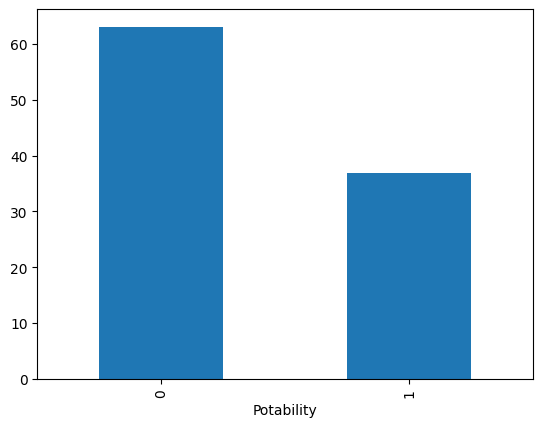

In [12]:
# Percentage of Potability classes
potability_missing_percent = (
    missing_rows['Potability']
    .value_counts(normalize=True)
    .sort_index() * 100
)

potability_missing_percent.plot(kind='bar')

# plt.title('Potability Distribution Among Rows with Missing Values')
# plt.xlabel('Potability')
# plt.ylabel('Percentage (%)')
# plt.xticks(rotation=0)
# plt.ylim(0, 100)

# plt.show()